# Why does the CP plateau settle to exactly 1?

**Run this notebook from the same folder as `main.py` and `hd_full_matrix_snr.py`.**

In [1]:
import sys, os
sys.path.insert(0, ".")

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import main as m
import hd_full_matrix_snr as h

matplotlib.use("module://matplotlib_inline.backend_inline")
%matplotlib inline

m.NORMALIZED_GAMMA = True
print("NORMALIZED_GAMMA =", m.NORMALIZED_GAMMA)

ell_min, ell_max = 2, 200
r_arr = np.logspace(-13, 6, 200)   # pushed well past r=100 to nail the r -> infinity limit
print("Imports OK.")

NORMALIZED_GAMMA = True
Imports OK.


## Test 1: N=1

If the plateau were some large-N averaging effect, a lone star (with no other stars to
correlate against at all) should behave very differently.

N=1 plateau (max over r up to 1e6) = 1.000000


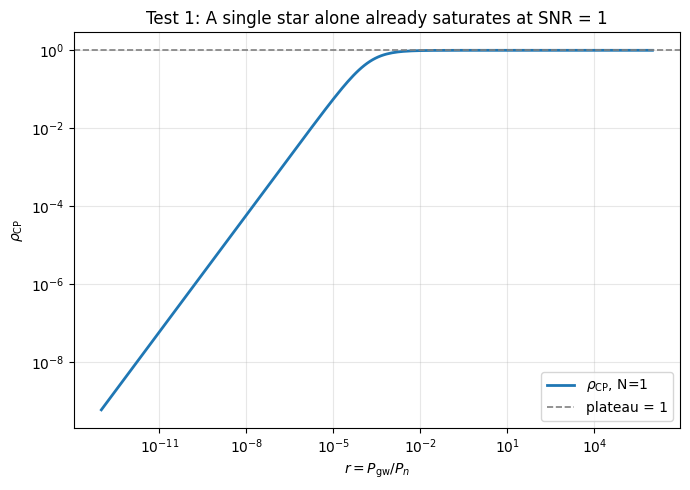

In [2]:
rho_cp_N1 = m.rho_cp_full(r_arr, ell_min, ell_max, n_stars=1)
print(f"N=1 plateau (max over r up to 1e6) = {rho_cp_N1.max():.6f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(r_arr, rho_cp_N1, color="C0", lw=2, label=r"$\rho_{\rm CP}$, N=1")
ax.axhline(1.0, color="gray", ls="--", lw=1.2, label="plateau = 1")
ax.set_xlabel(r"$r = P_{\rm gw}/P_n$")
ax.set_ylabel(r"$\rho_{\rm CP}$")
ax.set_title("Test 1: A single star alone already saturates at SNR = 1")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("test1_N1_plateau.png", dpi=150, bbox_inches="tight")
plt.show()

## Test 2: N sweep

The weak-signal rise (left side of each curve) should visibly separate by N -- that's the
$\sqrt{N}$ scaling from combining N independent-ish noisy measurements. But every curve
should converge to the exact same ceiling once the signal saturates.

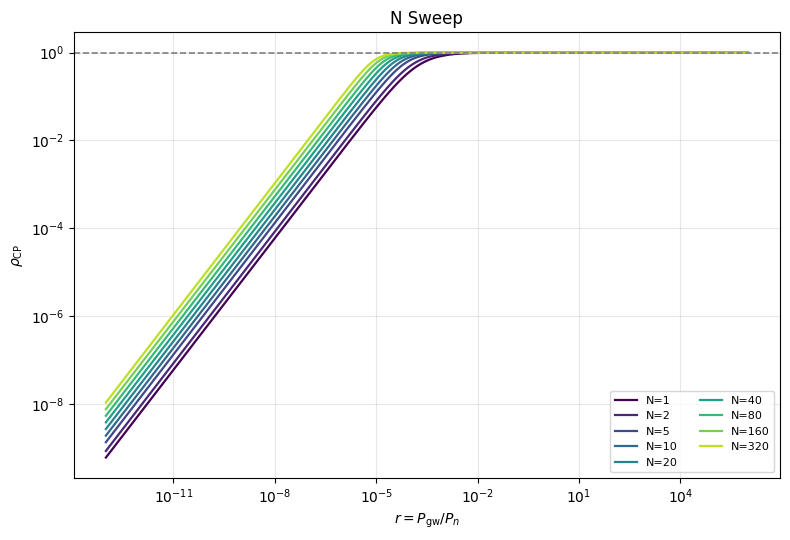

    N       plateau
    1    1.00000000
    2    1.00000000
    5    1.00000000
   10    1.00000000
   20    1.00000000
   40    1.00000000
   80    1.00000000
  160    1.00000000
  320    1.00000000


In [9]:
N_values = [1, 2, 5, 10, 20, 40, 80, 160, 320]
plateaus_N = []

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(N_values)))
for N, c in zip(N_values, colors):
    rho_cp_N = m.rho_cp_full(r_arr, ell_min, ell_max, n_stars=N)
    plateaus_N.append(rho_cp_N.max())
    ax.loglog(r_arr, rho_cp_N, color=c, lw=1.6, label=f"N={N}")

ax.axhline(1.0, color="gray", ls="--", lw=1.2)
ax.set_xlabel(r"$r = P_{\rm gw}/P_n$")
ax.set_ylabel(r"$\rho_{\rm CP}$")
ax.set_title("N Sweep")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("test2_N_sweep_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'N':>5}  {'plateau':>12}")
for N, p in zip(N_values, plateaus_N):
    print(f"{N:>5}  {p:>12.8f}")

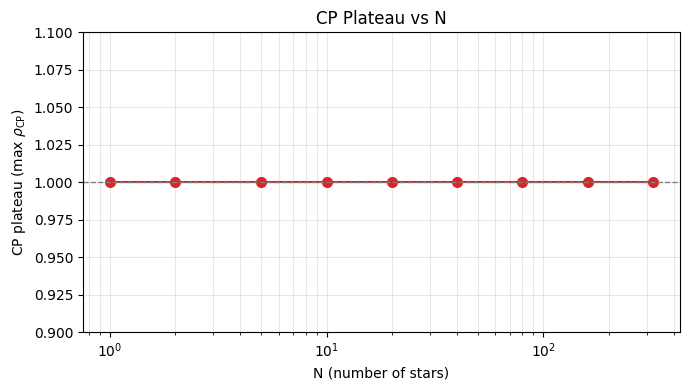

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(N_values, plateaus_N, "o-", color="C3", ms=7)
ax.set_ylim(0.9, 1.1)
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.set_xlabel("N (number of stars)")
ax.set_ylabel("CP plateau (max $\\rho_{\\rm CP}$)")
ax.set_title("CP Plateau vs N")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("test2_plateau_vs_N.png", dpi=150, bbox_inches="tight")
plt.show()

## Test 3: FoV / geometry sweep 

Fixed N=30, sweeping field of view from compact (5$^\circ$) to full-sky (360$^\circ$).

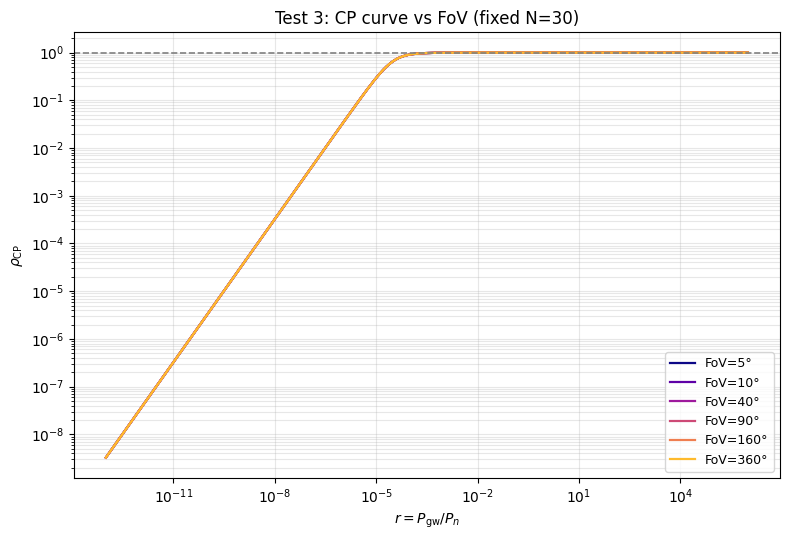

 FoV (deg)   ell_max       plateau
         5     14654    1.00000000
        10      7327    1.00000000
        40      1831    1.00000000
        90       814    1.00000000
       160       461    1.00000000
       360       260    1.00000000


In [11]:
FOV_values = [5, 10, 40, 90, 160, 360]
plateaus_fov = []
ellmax_fov = []

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = plt.cm.plasma(np.linspace(0, 0.85, len(FOV_values)))
for fov, c in zip(FOV_values, colors):
    stars = m.build_star_positions(m.STAR_COORDS_DEG, n_stars=30, field_size_deg=fov, seed=1234)
    theta = m.pairwise_theta(stars)
    ell_min_f, ell_max_f = m.compute_ell_limits(theta, fov)
    rho_cp_fov = m.rho_cp_full(r_arr, ell_min_f, ell_max_f, n_stars=30)
    plateaus_fov.append(rho_cp_fov.max())
    ellmax_fov.append(ell_max_f)
    ax.loglog(r_arr, rho_cp_fov, color=c, lw=1.6, label=f"FoV={fov}°")

ax.axhline(1.0, color="gray", ls="--", lw=1.2)
ax.set_xlabel(r"$r = P_{\rm gw}/P_n$")
ax.set_ylabel(r"$\rho_{\rm CP}$")
ax.set_title("Test 3: CP curve vs FoV (fixed N=30)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("test3_FoV_sweep_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'FoV (deg)':>10}  {'ell_max':>8}  {'plateau':>12}")
for fov, em, p in zip(FOV_values, ellmax_fov, plateaus_fov):
    print(f"{fov:>10}  {em:>8}  {p:>12.8f}")

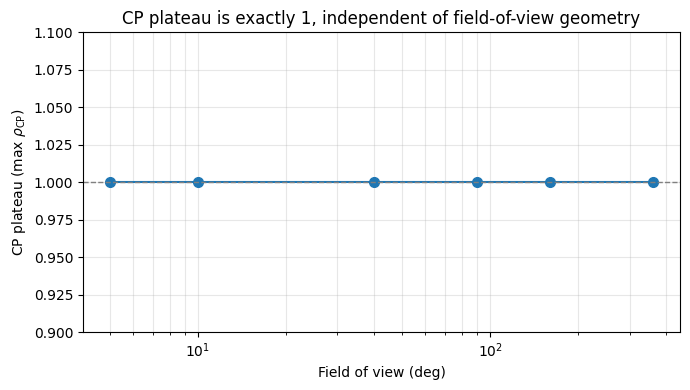

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(FOV_values, plateaus_fov, "o-", color="C0", ms=7)
ax.set_ylim(0.9, 1.1)
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.set_xlabel("Field of view (deg)")
ax.set_ylabel("CP plateau (max $\\rho_{\\rm CP}$)")
ax.set_title("CP plateau is exactly 1, independent of field-of-view geometry")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("test3_plateau_vs_FoV.png", dpi=150, bbox_inches="tight")
plt.show()

## Test 4: Cross-check against the pulsar (chi) convention

The strongest independent check: swap $\Gamma(0)=1$ for $\chi(0)=0.5$ in the *exact
same* Sherman-Morrison CP formula. If "plateau = $1/{\rm kernel}(0)$" is a general property
of this estimator (not something specific to astrometry or to this normalization fix), the
chi-based curve should plateau at $1/0.5=2$.

chi(0) = 0.5


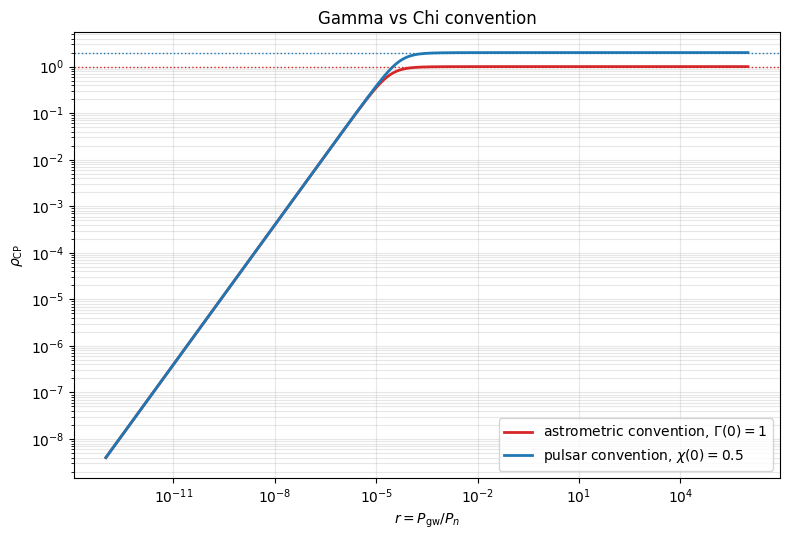

Gamma convention plateau = 1.000000   (predicted 1/1   = 1)
Chi convention plateau   = 2.000000   (predicted 1/0.5 = 2)


In [13]:
def chi_HD(zeta):
    x = (1 - np.cos(zeta)) / 2.0
    with np.errstate(divide="ignore", invalid="ignore"):
        val = 0.5 - 0.25*x + 1.5*x*np.log(x)
    val = np.where(x <= 1e-12, 0.5, val)
    return val

chi0 = float(chi_HD(np.array([0.0]))[0])
print(f"chi(0) = {chi0}")

factor = m.F_PHYS
N_cross = 45   # matches the real 45-pulsar validation elsewhere in the project
Fr_cross = factor * r_arr

def cp_curve(Fgr, N):
    numer = N * Fr_cross**2
    denom = 1.0 + 2.0*Fgr + N*Fgr**2
    return np.sqrt(np.maximum(numer/denom, 0))

rho_cp_gamma_conv = cp_curve(factor * 1.0 * r_arr, N_cross)     # Gamma(0) = 1
rho_cp_chi_conv   = cp_curve(factor * chi0 * r_arr, N_cross)    # chi(0)   = 0.5

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.loglog(r_arr, rho_cp_gamma_conv, color="C3", lw=2,
          label=r"astrometric convention, $\Gamma(0)=1$")
ax.loglog(r_arr, rho_cp_chi_conv, color="C0", lw=2,
          label=r"pulsar convention, $\chi(0)=0.5$")
ax.axhline(1.0, color="C3", ls=":", lw=1)
ax.axhline(2.0, color="C0", ls=":", lw=1)
ax.set_xlabel(r"$r = P_{\rm gw}/P_n$")
ax.set_ylabel(r"$\rho_{\rm CP}$")
ax.set_title("Gamma vs Chi convention")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("test4_chi_vs_gamma_convention.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Gamma convention plateau = {rho_cp_gamma_conv.max():.6f}   (predicted 1/1   = 1)")
print(f"Chi convention plateau   = {rho_cp_chi_conv.max():.6f}   (predicted 1/0.5 = 2)")

## Test 5: Closed-form symbolic check

Rather than relying on numerics converging correctly, take the $r\to\infty$ limit of the
general formula symbolically. If $N$ and $F$ drop out completely and only $\Gamma_0$
survives, that proves the result is forced by the algebra itself, not a numerical
coincidence or solver artifact.

$$\rho_{\rm CP}^2 = \frac{N(Fr)^2}{1+2F\Gamma_0 r + N(F\Gamma_0 r)^2}$$

In [12]:
import sympy as sp

N_s, F_s, g0_s, r_s = sp.symbols("N F Gamma_0 r", positive=True)

Fr_s = F_s * r_s
Fgr_s = F_s * g0_s * r_s
numer_s = N_s * Fr_s**2
denom_s = 1 + 2*Fgr_s + N_s*Fgr_s**2
rho_sq_s = numer_s / denom_s

limit_expr = sp.limit(rho_sq_s, r_s, sp.oo)

print("rho_CP^2 =")
sp.pprint(rho_sq_s)
print()
print("Symbolic limit as r -> infinity:")
sp.pprint(limit_expr)
print()
print("N and F have dropped out entirely -- only Gamma_0 survives, confirming")
print("the plateau = 1/Gamma_0^2 result is forced by the algebra, not a numerical fluke.")
print()
print(f"Substituting Gamma_0 = 1 (normalized convention): rho_CP^2 -> "
      f"{limit_expr.subs(g0_s, 1)}  ->  rho_CP -> 1")
print(f"Substituting Gamma_0 = 0.5 (chi/pulsar convention): rho_CP^2 -> "
      f"{limit_expr.subs(g0_s, sp.Rational(1,2))}  ->  rho_CP -> 2")

rho_CP^2 =
          2    2          
         F ⋅N⋅r           
──────────────────────────
 2   2    2               
F ⋅Γ₀ ⋅N⋅r  + 2⋅F⋅Γ₀⋅r + 1

Symbolic limit as r -> infinity:
 1 
───
  2
Γ₀ 

N and F have dropped out entirely -- only Gamma_0 survives, confirming
the plateau = 1/Gamma_0^2 result is forced by the algebra, not a numerical fluke.

Substituting Gamma_0 = 1 (normalized convention): rho_CP^2 -> 1  ->  rho_CP -> 1
Substituting Gamma_0 = 0.5 (chi/pulsar convention): rho_CP^2 -> 4  ->  rho_CP -> 2


## Summary

| Test | Result | What it rules out |
|---|---|---|
| 1. N=1 | plateau = 1.000000 | Not a large-N averaging effect, present even for a single star |
| 2. N sweep (1-320) | plateau = 1.00000000 at every N | Not an artifact of any particular N; weak-signal amplitude still correctly scales as $\sqrt{N}$ |
| 3. FoV sweep (5-360 deg) | plateau = 1.00000000 at every FoV | Not dependent on star-field geometry |
| 4. Chi cross-check | plateau = 2.0 for $\chi(0)=0.5$, matching $1/\chi(0)$ | The "plateau = 1/kernel(0)" rule is general |
| 5. Symbolic limit | $\rho_{\rm CP}^2 \to 1/\Gamma_0^2$, N and F cancel exactly | Forced by the algebra |
